# Convertible-Bond Daily Trading Factors

## TL;DR

This report documents the point-in-time construction and data-quality controls for convertible-bond trading factors. All displayed counts, dates, coverage rates, unit checks, distribution statistics, and rank correlations are read from the existing G3 audit artifacts or factor panel. It evaluates definitions, units, and information overlap only; it does not load an outcome label or assess trading performance.

## Context & Methods

### Glossary and source units

- **Convertible Bond (CB):** a bond that can be converted into the issuer's equity under specified terms.
- **Volume-Weighted Average Price (VWAP):** transaction amount divided by the number of bonds traded, expressed as price per bond.
- **Chinese yuan (CNY):** the reporting currency for transaction amount.
- **Z-score:** a standard score measuring distance from a prior-window mean in prior-window standard deviations.
- **Amihud illiquidity:** absolute price movement per unit of actual transaction amount; larger values indicate greater price impact.

Tushare convertible-bond daily fields use two different source scales that must not be conflated:

- Volume (`vol`) is reported in hands of ten bonds.
- Amount (`amount`) is reported in ten-thousand CNY.
- Per-bond VWAP is therefore `amount * 1,000 / vol`, equivalently `amount * 10,000 / (vol * 10)`.
- Actual transaction notional for log amount and Amihud is `amount * 10,000` CNY.

### Factor families and economic interpretation

| Family | Construction | Economic interpretation |
|---|---|---|
| Price trend | Raw-close returns over 5, 10, and 20 market days; 5-day return minus 20-day return | Recent direction and short-versus-long trend shape |
| Trading activity | Daily turnover; 20- and 60-day abnormal turnover; 20-day log-amount Z-score | Participation relative to remaining principal and the bond's own prior history |
| Liquidity | 20-day Amihud illiquidity | Absolute return per CNY of actual transaction notional |
| Intraday pressure | Close relative to VWAP; five-day mean close-to-VWAP deviation | Whether trading ends above or below the day's volume-weighted consensus price |

### Timing and missing-data rules

- Signals use data available through the signal-date close.
- Rolling windows require at least 80% valid observations.
- Abnormal turnover and the amount Z-score compare the current observation with a prior window that excludes the current day.
- Remaining principal is reconstructed point in time from share-change events; issue size is used before the first valid event.
- A source row with both `vol = 0` and `amount = 0` is an observed zero-trading row: daily turnover is zero and is a valid rolling-turnover observation.
- A calendar bond-date with no source market row is an unknown data gap, not an inferred suspension. Price, return, volume, amount, turnover, VWAP, and dependent factors remain missing and are never forward-filled.
- Rolling abnormal turnover applies the 80% rule to genuinely observed rows; observed zero-turnover rows count, while unknown gaps do not enter the mean or observation count.
- Zero-volume rows cannot produce VWAP. VWAP, log amount, Amihud, and current or rolling close-to-VWAP factors remain missing on that date.
- A positive amount-volume pair is accepted for VWAP-dependent calculations only when inferred VWAP lies within the reported daily low-high range, allowing a CNY 0.02 tolerance.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from cb_quant.cb_trading import CB_TRADING_FACTOR_COLUMNS
from cb_quant.notebook_quality import build_lineage_gate
from cb_quant.plotting import configure_matplotlib

configure_matplotlib()
ARTIFACT_ROOT = PROJECT_ROOT / "artifacts" / "G3"
ASSET_ROOT = PROJECT_ROOT / "docs" / "assets"
ASSET_ROOT.mkdir(parents=True, exist_ok=True)

panel_files = sorted(
    (ARTIFACT_ROOT / "cb_trading_factor_panel_v1").glob("year=*/part-*.parquet")
)
assert panel_files, "Stored G3 CB-trading panel partitions are missing"
panel = pd.concat((pd.read_parquet(path) for path in panel_files), ignore_index=True)
panel["signal_date"] = pd.to_datetime(panel["signal_date"])
audit = json.loads(
    (ARTIFACT_ROOT / "cb_trading_factor_audit_v1.json").read_text(encoding="utf-8")
)
stage_audit_paths = {
    "G0": PROJECT_ROOT / "artifacts/G0/research_config_validation_v1.json",
    "G1": PROJECT_ROOT / "artifacts/G1/universe_audit_v1.json",
    "G2": PROJECT_ROOT / "artifacts/G2/valuation_factor_audit_v1.json",
    "G3a": PROJECT_ROOT / "artifacts/G3/stock_linkage_factor_audit_v1.json",
    "G3b": PROJECT_ROOT / "artifacts/G3/cb_trading_factor_audit_v1.json",
}
stage_audits = {
    stage: json.loads(path.read_text(encoding="utf-8"))
    for stage, path in stage_audit_paths.items()
}
lineage_gate = build_lineage_gate(stage_audits)
anomaly_review = pd.read_parquet(
    ARTIFACT_ROOT / "cb_trading_anomaly_review_v1.parquet"
)

FACTOR_LABELS = {
    "cb_return_5d": "CB return (5d)",
    "cb_return_10d": "CB return (10d)",
    "cb_return_20d": "CB return (20d)",
    "cb_short_long_momentum_5_20d": "Momentum (5d - 20d)",
    "cb_daily_turnover": "Daily turnover",
    "cb_abnormal_turnover_20d": "Abnormal turnover (20d)",
    "cb_abnormal_turnover_60d": "Abnormal turnover (60d)",
    "cb_log_amount_zscore_20d": "Log-amount Z-score (20d)",
    "cb_amihud_20d": "Amihud illiquidity (20d)",
    "cb_close_to_vwap": "Close-to-VWAP",
    "cb_close_to_vwap_mean_5d": "Mean close-to-VWAP (5d)",
}

## Data Quality Gate

The release gate verifies exact G1 key alignment, unique bond-date observations, independently replicated formulas, factor coverage, source-unit inference, and the conservative distinction between observed zero trading and an unknown missing source row. The range check uses the full stored daily history, while the signal-date exclusion count identifies amount-volume records withheld from amount-dependent factors without discarding valid close-based returns.

In [2]:
assert audit["status"] == "pass"
assert lineage_gate["status"] == "pass"
assert audit["duplicate_signal_bond_keys"] == 0
assert audit["missing_expected_keys"] == 0
assert audit["extra_unexpected_keys"] == 0
assert audit["formula_mismatch_count"] == 0
assert audit["vwap_range_check_passed"]
assert set(audit["missing_data_policy"]) == {
    "observed_zero_trade", "unknown_market_gap", "rolling_turnover"
}
assert len(panel) == audit["row_count"]
assert panel["signal_date"].nunique() == audit["signal_date_count"]
assert set(audit["factor_coverage"]) == set(CB_TRADING_FACTOR_COLUMNS)
assert audit["vwap_excluded_count"] == int((~panel["cb_vwap_unit_valid"]).sum())
assert not panel.duplicated(["signal_date", "ts_code"]).any()

coverage = pd.Series(audit["factor_coverage"], name="Coverage")
unit_audit = audit["full_history_vwap_unit_audit"]
quality_summary = pd.DataFrame(
    {
        "Metric": [
            "Audit status",
            "Lineage gate",
            "Panel observations",
            "Signal dates",
            "Factor count",
            "Coverage range",
            "Key mismatches",
            "Formula mismatches",
            "Full-history VWAP checks",
            "VWAP range-check rate",
            "Signal-date exclusions",
            "Anomaly-review rows",
            "Missing-data distinction",
            "Sample period",
        ],
        "Observed value": [
            audit["status"],
            lineage_gate["detail"],
            f"{audit['row_count']:,}",
            f"{audit['signal_date_count']:,}",
            f"{len(audit['factor_coverage']):,}",
            f"{coverage.min():.2%} to {coverage.max():.2%}",
            f"{audit['missing_expected_keys'] + audit['extra_unexpected_keys']:,}",
            f"{audit['formula_mismatch_count']:,}",
            f"{unit_audit['valid_row_count']:,}",
            f"{unit_audit['inside_daily_range_rate']:.5%}",
            f"{audit['vwap_excluded_count']:,}",
            f"{len(anomaly_review):,}",
            "Observed zero trading separated from unknown gaps",
            f"{audit['sample_start']} to {audit['sample_end']}",
        ],
    }
)
display(quality_summary)

excluded_columns = [
    "signal_date", "ts_code", "cb_low", "cb_high", "cb_close",
    "cb_vol", "cb_amount", "cb_vwap", "cb_return_5d", "cb_return_20d",
]
excluded = panel.loc[~panel["cb_vwap_unit_valid"], excluded_columns].copy()
excluded["raw_inferred_vwap"] = excluded["cb_amount"] * 1_000.0 / excluded["cb_vol"]
display(excluded)

,Metric,Observed value
0,Audit status,pass
1,Lineage gate,Stored stage configuration fingerprints match.
2,Panel observations,"44,728"
3,Signal dates,222
4,Factor count,11
5,Coverage range,95.48% to 100.00%
6,Key mismatches,0
7,Formula mismatches,0
8,Full-history VWAP checks,"729,970"
9,VWAP range-check rate,99.99507%


,signal_date,ts_code,cb_low,cb_high,cb_close,cb_vol,cb_amount,cb_vwap,cb_return_5d,cb_return_20d,raw_inferred_vwap
3272,2019-07-24,110046.SH,115.01,116.7,115.87,41047.0,3768.5687,NaN,-0.003012,-0.002754,91.811063


## Results

Coverage is displayed on its full observed comparison range. The correlation panel uses the complete `[-1, 1]` color scale. Distribution statistics come from stored audit quantiles, and the reported annual VWAP exception rates are derived from the full-history unit audit.

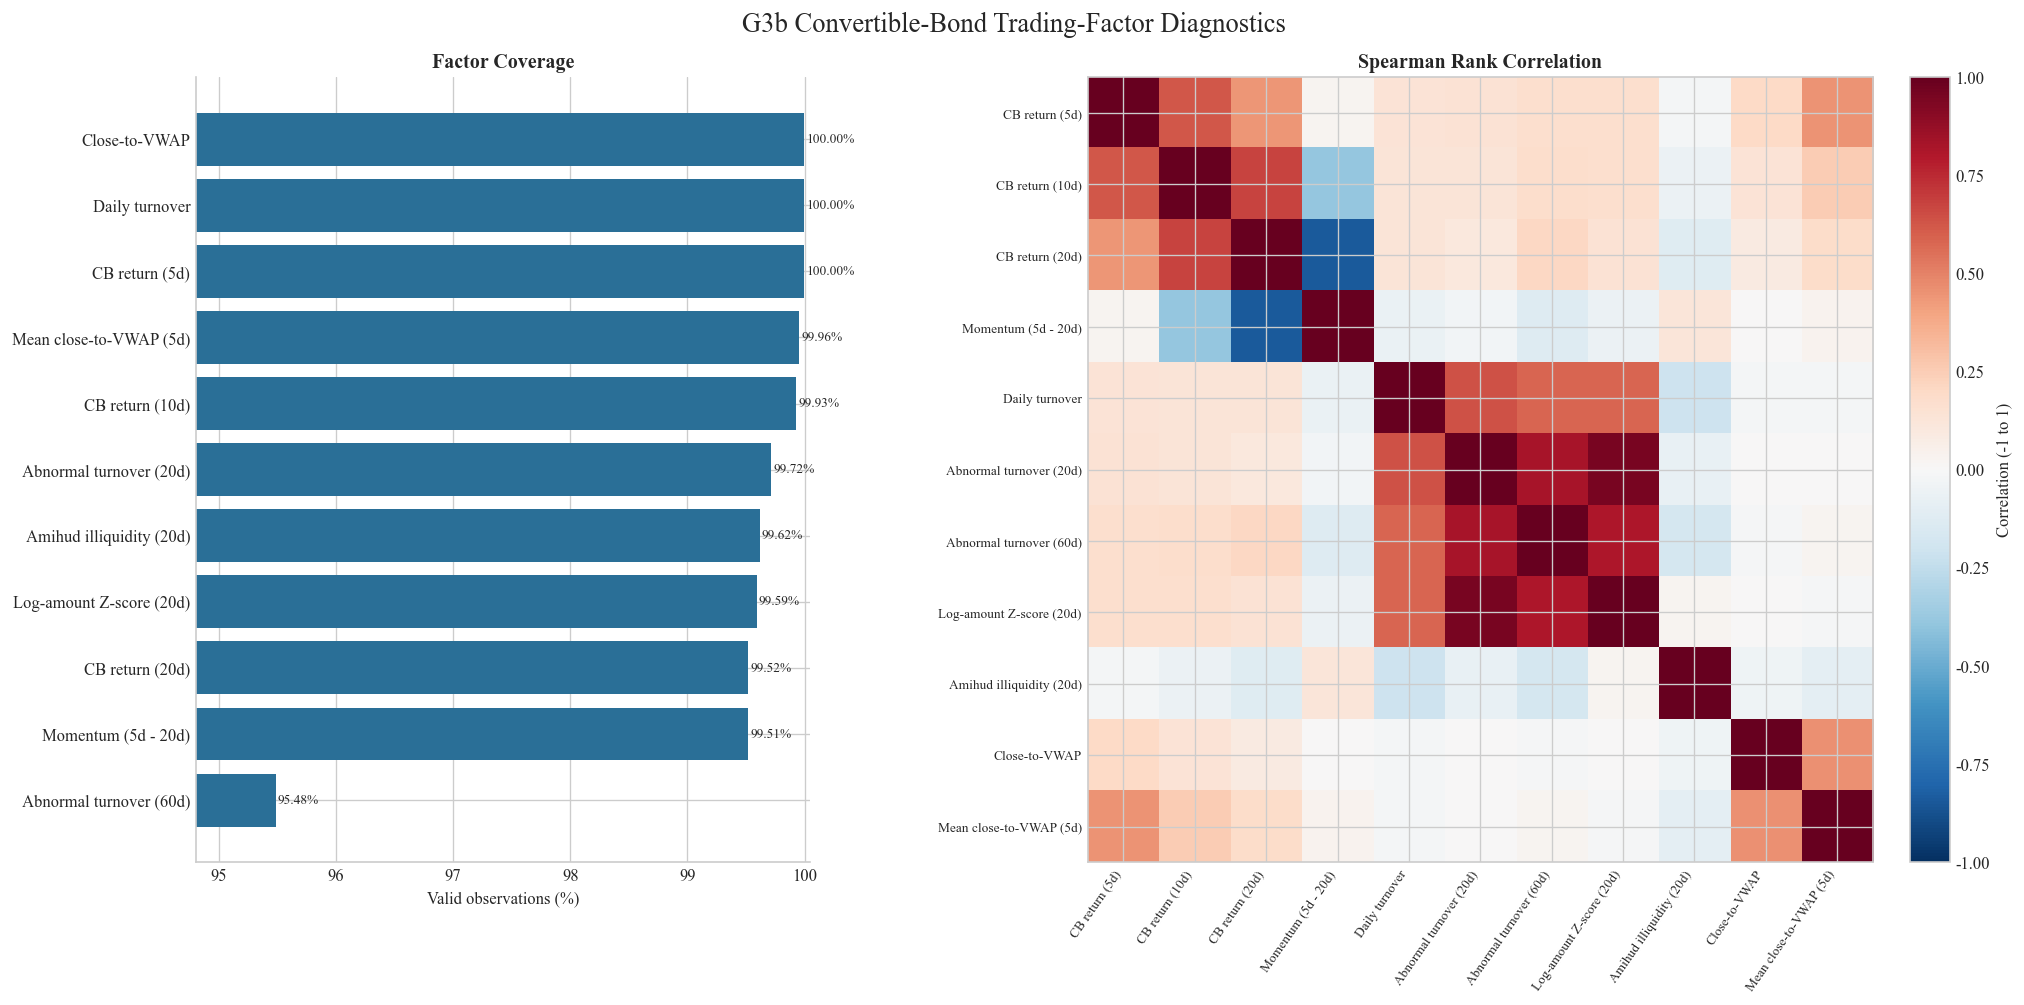

In [3]:
coverage = coverage.reindex(CB_TRADING_FACTOR_COLUMNS).sort_values()
correlation = pd.DataFrame(audit["factor_spearman_correlation"]).loc[
    CB_TRADING_FACTOR_COLUMNS, CB_TRADING_FACTOR_COLUMNS
]

fig, axes = plt.subplots(1, 2, figsize=(17, 8.5), gridspec_kw={"width_ratios": [0.85, 1.3]})

coverage_values = coverage * 100
axes[0].barh(
    [FACTOR_LABELS[factor] for factor in coverage.index],
    coverage_values,
    color="#2A6F97",
)
coverage_margin = max(0.15, (coverage_values.max() - coverage_values.min()) * 0.15)
axes[0].set_xlim(coverage_values.min() - coverage_margin, 100.05)
axes[0].set_xlabel("Valid observations (%)")
axes[0].set_title("Factor Coverage")
for row, value in enumerate(coverage_values):
    axes[0].text(value + 0.02, row, f"{value:.2f}%", va="center", fontsize=8)
axes[0].spines[["top", "right"]].set_visible(False)

labels = [FACTOR_LABELS[factor] for factor in CB_TRADING_FACTOR_COLUMNS]
image = axes[1].imshow(correlation, cmap="RdBu_r", vmin=-1, vmax=1)
axes[1].set_xticks(range(len(labels)), labels=labels, rotation=55, ha="right", fontsize=8)
axes[1].set_yticks(range(len(labels)), labels=labels, fontsize=8)
axes[1].set_title("Spearman Rank Correlation")
fig.colorbar(image, ax=axes[1], fraction=0.046, pad=0.04, label="Correlation (-1 to 1)")

fig.suptitle("G3b Convertible-Bond Trading-Factor Diagnostics", fontsize=16)
fig.tight_layout()
asset_path = ASSET_ROOT / "g3b_cb_trading_diagnostics.png"
fig.savefig(asset_path, dpi=140, bbox_inches="tight")
plt.show()

In [4]:
distribution_summary = (
    pd.DataFrame(audit["factor_quantiles"])
    .T[["0.01", "0.05", "0.5", "0.95", "0.99"]]
    .rename(index=FACTOR_LABELS)
    .rename(columns={"0.01": "P01", "0.05": "P05", "0.5": "Median", "0.95": "P95", "0.99": "P99"})
)

annual_unit_check = pd.DataFrame(unit_audit["by_year"]).T
annual_unit_check.index.name = "Year"
annual_unit_check = annual_unit_check[["count", "inside_daily_range_rate"]].rename(
    columns={"count": "Valid rows", "inside_daily_range_rate": "Inside-range rate"}
)

pairs = []
for left_index, left in enumerate(CB_TRADING_FACTOR_COLUMNS):
    for right in CB_TRADING_FACTOR_COLUMNS[left_index + 1:]:
        value = correlation.loc[left, right]
        pairs.append(
            {
                "Factor A": FACTOR_LABELS[left],
                "Factor B": FACTOR_LABELS[right],
                "Spearman correlation": value,
                "Absolute correlation": abs(value),
            }
        )
rank_overlap = (
    pd.DataFrame(pairs)
    .sort_values("Absolute correlation", ascending=False)
    .head(8)
    .drop(columns="Absolute correlation")
)

display(distribution_summary.style.format("{:.4f}"))
display(annual_unit_check.style.format({"Valid rows": "{:,.0f}", "Inside-range rate": "{:.5%}"}))
display(rank_overlap.style.format({"Spearman correlation": "{:.3f}"}))

,P01,P05,Median,P95,P99
CB return (5d),-0.0553,-0.0315,0.0002,0.0370,0.0667
CB return (10d),-0.0807,-0.0471,0.0002,0.0459,0.0842
CB return (20d),-0.1087,-0.0673,-0.0013,0.0644,0.1133
Momentum (5d - 20d),-0.0903,-0.0519,0.0011,0.0612,0.1019
Daily turnover,0.0007,0.0020,0.0123,0.0570,0.1181
Abnormal turnover (20d),0.1166,0.2314,0.7758,2.6820,5.8470
Abnormal turnover (60d),0.0584,0.1401,0.6658,2.6378,5.8340
Log-amount Z-score (20d),-2.7895,-1.9518,-0.1245,1.9700,3.3423
Amihud illiquidity (20d),0.0010,0.0048,0.0406,0.2184,0.5243
Close-to-VWAP,-0.0166,-0.0080,-0.0003,0.0058,0.0114


,Valid rows,Inside-range rate
Year,,
2018,"20,945",99.97613%
2019,"41,635",99.98559%
2020,"68,735",99.98545%
2021,"90,908",99.99010%
2022,"102,400",99.99414%
2023,"123,526",100.00000%
2024,"129,536",100.00000%
2025,"110,374",100.00000%
2026,"41,911",100.00000%


,Factor A,Factor B,Spearman correlation
41,Abnormal turnover (20d),Log-amount Z-score (20d),0.947
19,CB return (20d),Momentum (5d - 20d),-0.837
40,Abnormal turnover (20d),Abnormal turnover (60d),0.822
45,Abnormal turnover (60d),Log-amount Z-score (20d),0.807
10,CB return (10d),CB return (20d),0.674
34,Daily turnover,Abnormal turnover (20d),0.635
0,CB return (5d),CB return (10d),0.623
35,Daily turnover,Abnormal turnover (60d),0.586


## Takeaways

1. The stored panel, investable keys, and independently replicated formulas pass the documented quality gate.
2. The Tushare source-unit convention is internally consistent: per-bond VWAP uses the hand conversion, while Amihud and log amount use actual CNY notional.
3. The amount-volume quality rule is narrow. It withholds amount-dependent fields for inconsistent records while preserving valid close-based return fields.
4. Observed zero trading and unknown missing rows are not interchangeable: the former contributes zero turnover, while the latter remains missing and is excluded from rolling turnover baselines.
5. Coverage remains high across short and long point-in-time windows; missing histories are retained rather than filled.
6. Activity factors contain substantial rank overlap, which should be addressed explicitly during later preprocessing and feature combination.
7. This stage freezes transparent raw definitions and quality evidence without interpreting them as trading signals.